# Model Comparison and Joint Analysis

## Objective
Everything up to this point gives me four things to compare: the Wisconsin tabular model, the corrected BreaKHis image model, and the synthetic fusion variants. This notebook puts them side by side so I can answer the real project question directly: where each branch is strong, what changes under synthetic fusion, and which improvements look more like pairing artefacts than genuine extra signal.


## Notebook Purpose

This notebook brings the tabular, image, and synthetic-fusion results into one comparison frame. It is designed to answer what each model family contributes and what can safely be claimed.


## Why This Matters

The dissertation needs a joint interpretation rather than separate isolated result tables. This notebook separates reused comparator evidence, new image-model evidence, and exploratory fusion evidence.


## Load Cross-Branch Results

This setup cell reads the key outputs from the Wisconsin review, BreaKHis evaluation, and fusion experiments. It prepares the data needed for one consistent comparison table.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from src.fusion import comparison_table
from src.metrics import save_metric_barplot

wisconsin_metrics = pd.read_csv(REPORTS / 'wisconsin_published_metrics.csv')
breakhis_metrics = pd.read_csv(METRICS / 'breakhis_patient_level_metrics.csv')
fusion_summary = pd.read_csv(METRICS / 'synthetic_fusion_summary.csv')


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs


## Build Joint Comparison Table

This cell constructs a compact table with family, model name, accuracy, ROC-AUC, stability/calibration note, and claim type. The `claim_type` column is important because not every metric has the same evidential status.


In [2]:
rows = [
    {
        'family': 'monomodel',
        'model': 'Wisconsin published branch',
        'accuracy': float(wisconsin_metrics[wisconsin_metrics['metric'] == 'accuracy']['value'].iloc[0]),
        'roc_auc': float(wisconsin_metrics[wisconsin_metrics['metric'] == 'roc_auc']['value'].iloc[0]),
        'calibration_or_stability': 'MC Dropout reported in source notebook',
        'claim_type': 'published Wisconsin branch',
    },
    {
        'family': 'monomodel',
        'model': 'BreaKHis corrected patient-level model',
        'accuracy': float(breakhis_metrics['accuracy'].iloc[0]),
        'roc_auc': float(breakhis_metrics['roc_auc'].iloc[0]),
        'calibration_or_stability': f"ECE={breakhis_metrics['ece'].iloc[0]:.3f}",
        'claim_type': 'main new image result',
    },
]
for pairing_type, experiment in [('same_label', 'early_fusion'), ('random', 'early_fusion'), ('random', 'late_fusion')]:
    subset = fusion_summary[(fusion_summary['pairing_type'] == pairing_type) & (fusion_summary['experiment'] == experiment)]
    rows.append(
        {
            'family': 'synthetic_fusion',
            'model': f'{pairing_type} | {experiment}',
            'accuracy': float(subset[subset['metric'] == 'accuracy']['mean'].iloc[0]),
            'roc_auc': float(subset[subset['metric'] == 'roc_auc']['mean'].iloc[0]),
            'calibration_or_stability': f"std_acc={subset[subset['metric'] == 'accuracy']['std'].iloc[0]:.3f}",
            'claim_type': 'exploratory only',
        }
    )
comparison_df = comparison_table(rows)
comparison_df.to_csv(METRICS / 'joint_model_comparison.csv', index=False)
comparison_df


,family,model,accuracy,roc_auc,calibration_or_stability,claim_type
0,monomodel,BreaKHis corrected patient-level model,0.769231,0.888889,ECE=0.235,main new image result
1,monomodel,Wisconsin published branch,0.960000,0.997000,MC Dropout reported in source notebook,published Wisconsin branch
2,synthetic_fusion,random | early_fusion,0.970175,0.994775,std_acc=0.010,exploratory only
3,synthetic_fusion,random | late_fusion,0.971930,0.990410,std_acc=0.010,exploratory only
4,synthetic_fusion,same_label | early_fusion,1.000000,1.000000,std_acc=0.000,exploratory only


## Save Comparison Figures

This cell creates accuracy and ROC-AUC comparison figures. These plots are intended for the final results/discussion sections where the model families are compared directly.


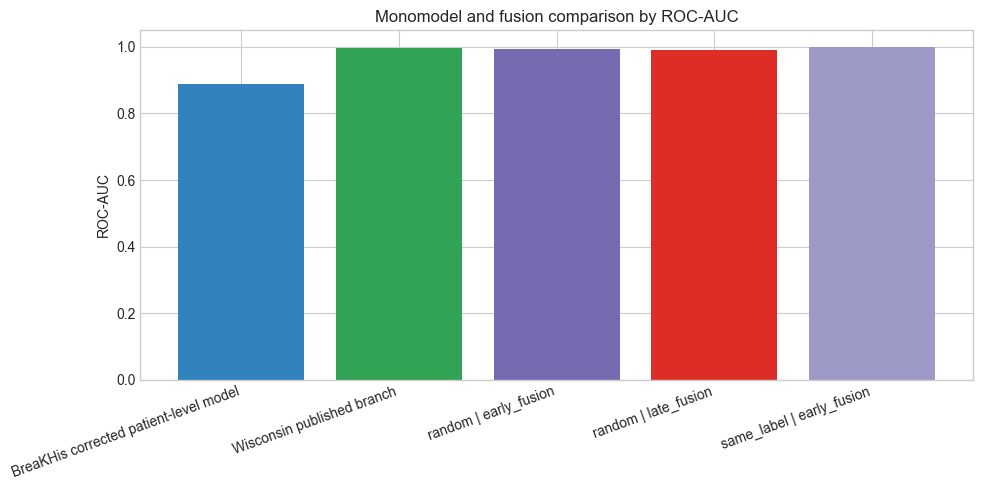

In [3]:
plot_df = comparison_df[['model', 'accuracy', 'family']]
save_metric_barplot(
    plot_df,
    x='model',
    y='accuracy',
    hue='family',
    output_path=FIGURES / 'joint_model_accuracy_comparison.png',
    title='Monomodel and fusion comparison by accuracy',
    ylabel='Accuracy',
)

plot_df_auc = comparison_df[['model', 'roc_auc', 'family']].rename(columns={'roc_auc': 'value'})
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df_auc['model'], plot_df_auc['value'], color=['#3182bd', '#31a354', '#756bb1', '#de2d26', '#9e9ac8'])
ax.set_title('Monomodel and fusion comparison by ROC-AUC')
ax.set_ylabel('ROC-AUC')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'joint_model_roc_auc_comparison.png', dpi=300)
plt.show()


## Synthesis Notes

This cell records plain-language answers to the main comparative questions. It helps translate metric tables into dissertation claims and caveats.


In [4]:
analysis_notes = pd.DataFrame(
    [
        {'question': 'Which monomodel is strongest on its own?', 'answer': 'The published Wisconsin branch reports the highest published metrics, but it remains a reused external component rather than new work.'},
        {'question': 'What is the main new image result?', 'answer': 'The corrected patient-level BreaKHis model provides the strongest new unimodal result because leakage is removed.'},
        {'question': 'Do synthetic fusion gains look genuine?', 'answer': 'Only cautiously. Same-label pairing inflates alignment, while random-pairing controls are much weaker.'},
        {'question': 'What should be claimed in the dissertation?', 'answer': 'Use the unimodal findings as the main results and keep synthetic fusion clearly exploratory.'},
    ]
)
analysis_notes


,question,answer
0,Which monomodel is strongest on its own?,The published Wisconsin branch reports the highes...
1,What is the main new image result?,The corrected patient-level BreaKHis model pro...
2,Do synthetic fusion gains look genuine?,Only cautiously. Same-label pairing inflates a...
3,What should be claimed in the dissertation?,Use the unimodal findings as the main resul...


## Interpretation

Putting the models side by side makes the trade-offs much clearer. The Wisconsin branch is still the strongest tabular component and it gives me a stable reference point. The corrected BreaKHis model is the main new image result because it is built on the patient-level split I actually trust. The synthetic fusion results are still useful, but mostly because they show how quickly artificial pairing can inflate the numbers. I expected fusion to help more than it really did once the control runs were included, and that ended up being part of the point.


## How This Notebook Supports The Dissertation

This notebook prevents the final discussion from becoming a list of disconnected experiments. It makes the hierarchy of evidence explicit: published tabular comparator, new patient-level image result, and exploratory synthetic fusion.
